**Modelo de Entrenamiento**

✅ Dependencias instaladas y configuradas
✅ Librerías de machine learning importadas
MLflow version: 3.14.0
📊 Tamaño de entrenamiento: 16512
📊 Tamaño de prueba: 4128
📊 Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

🚀 Entrenando modelos...

✅ Linear Regression: Test R² = 0.5758, Test RMSE = 0.7456
✅ Ridge Regression: Test R² = 0.5758, Test RMSE = 0.7456
✅ Lasso Regression: Test R² = 0.5816, Test RMSE = 0.7404
✅ Random Forest: Test R² = 0.8047, Test RMSE = 0.5059
✅ Gradient Boosting: Test R² = 0.7756, Test RMSE = 0.5422
✅ XGBoost: Test R² = 0.8367, Test RMSE = 0.4626
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001300 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947
[LightGBM] [Info] Auto-ch

,Modelo,Train_R2,Test_R2,Test_RMSE,Test_MAE,CV_Mean,CV_Std
6,LightGBM,0.883606,0.838610,0.459877,0.305458,0.834506,0.005371
5,XGBoost,0.943122,0.836659,0.462648,0.310742,0.829678,0.007241
3,Random Forest,0.973505,0.804706,0.505880,0.327766,0.804449,0.005251
4,Gradient Boosting,0.804898,0.775643,0.542217,0.371650,0.786548,0.003146
2,Lasso Regression,0.608474,0.581615,0.740442,0.535326,0.607662,0.004699
1,Ridge Regression,0.612551,0.575816,0.745557,0.533193,0.611484,0.006460
0,Linear Regression,0.612551,0.575788,0.745581,0.533200,0.611484,0.006467


✅ Resultados guardados como 'training_results.csv'


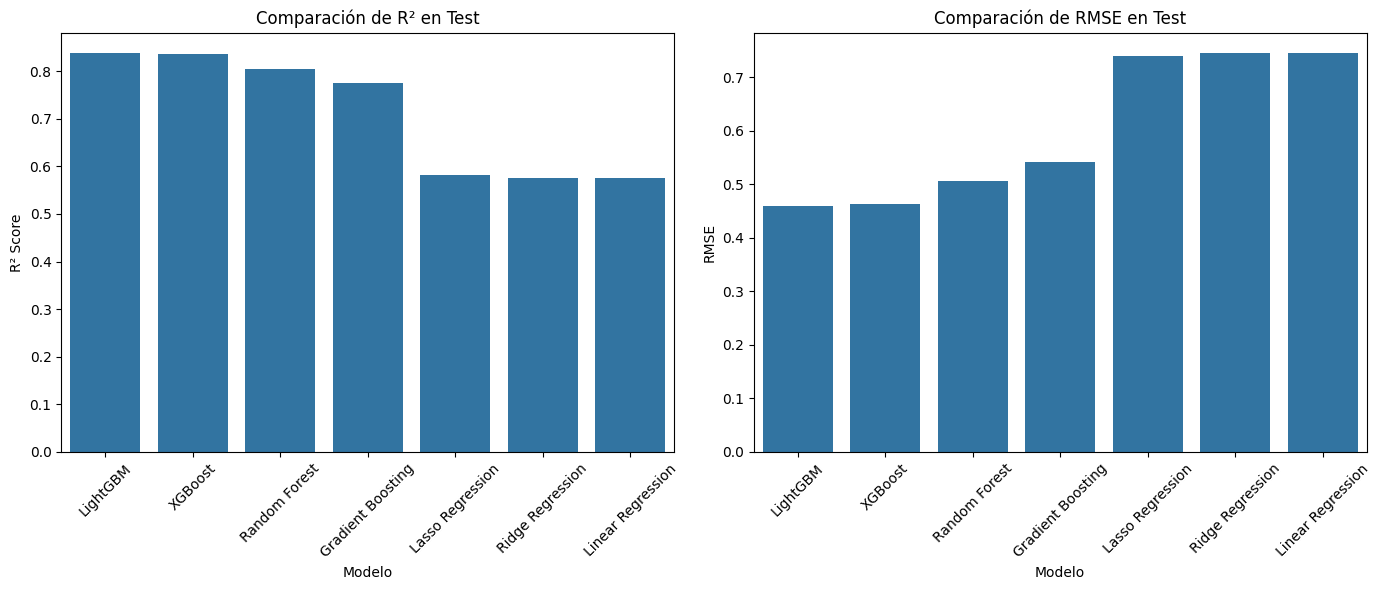

✅ Gráfico guardado como 'model_comparison.png'

🔍 Optimizando hiperparámetros para XGBoost...
✅ Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
✅ Mejor puntaje: 0.2113

📈 Modelo Optimizado:
  R²: 0.8461
  RMSE: 0.4491


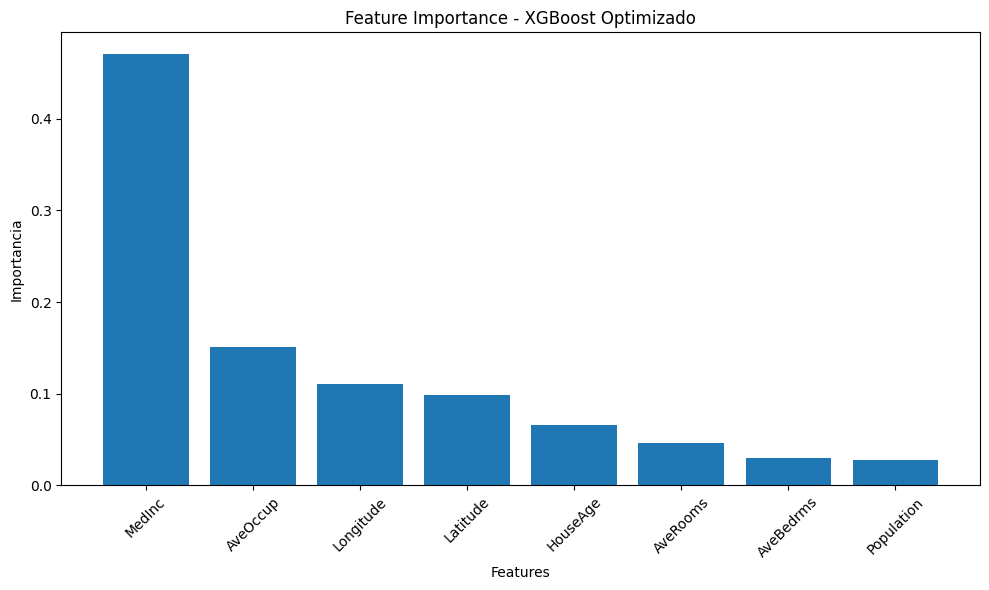

✅ Gráfico guardado como 'feature_importance.png'
✅ Modelo y scaler guardados como 'best_model.pkl' y 'scaler.pkl'

📊 RESUMEN DE ENTRENAMIENTO

🏆 Mejor Modelo: XGBoost Optimizado
📈 R² Score: 0.8461
📊 RMSE: 0.4491
🔧 Mejores Parámetros: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}

📁 ARCHIVOS GENERADOS:
----------------------------------------
  ✅ training_results.csv (0.9 KB)
  ✅ model_comparison.png (206.7 KB)
  ✅ feature_importance.png (142.2 KB)
  ✅ best_model.pkl (1338.8 KB)
  ✅ scaler.pkl (0.8 KB)

🎯 PRÓXIMO PASO: Ejecutar 03_model_evaluation.ipynb

📥 Descargando archivos generados...
  📦 training_results.csv añadido al ZIP
  📦 model_comparison.png añadido al ZIP
  📦 feature_importance.png añadido al ZIP
  📦 best_model.pkl añadido al ZIP
  📦 scaler.pkl añadido al ZIP


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ ¡Descarga completada!


In [6]:
import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger("mlflow").setLevel(logging.ERROR)
logging.getLogger("mlflow.models.model").setLevel(logging.ERROR)
logging.getLogger("mlflow.utils.requirements_utils").setLevel(logging.ERROR)
logging.getLogger("mlflow.store.db.utils").setLevel(logging.ERROR)
logging.getLogger("urllib3").setLevel(logging.ERROR)

print("✅ Dependencias instaladas y configuradas")

# Importación de librerías
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import joblib

print("✅ Librerías de machine learning importadas")
print(f"MLflow version: {mlflow.__version__}")

# Carga y preparación de datos
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
X = housing.data
y = housing.target

# 🔧 CORREGIDO: Nombres de features correctos
feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

# División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📊 Tamaño de entrenamiento: {X_train.shape[0]}")
print(f"📊 Tamaño de prueba: {X_test.shape[0]}")
print(f"📊 Features: {feature_names}")

# Configuración de MLflow
mlflow.set_experiment("california_housing_experiment")

# Diccionario de modelos a evaluar
models = {
    'Linear_Regression': LinearRegression(),
    'Ridge_Regression': Ridge(alpha=1.0),
    'Lasso_Regression': Lasso(alpha=0.01),
    'Random_Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient_Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42)
}

# Resultados de entrenamiento
results = []

print("\n🚀 Entrenando modelos...\n")

# 🔧 SILENCIAR ADVERTENCIAS DE MLflow
mlflow.autolog(disable=True)

# Definir tipos de skops_trusted_types para MLflow, incluyendo los de XGBoost y LightGBM
skops_trusted_types = [
    'collections.OrderedDict',
    'lightgbm.basic.Booster',
    'lightgbm.sklearn.LGBMRegressor',
    'xgboost.core.Booster',
    'xgboost.sklearn.XGBRegressor'
]

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        # Entrenamiento
        model.fit(X_train_scaled, y_train)

        # Predicciones
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)

        # Métricas
        train_mse = mean_squared_error(y_train, y_train_pred)
        train_rmse = np.sqrt(train_mse)
        train_mae = mean_absolute_error(y_train, y_train_pred)
        train_r2 = r2_score(y_train, y_train_pred)

        test_mse = mean_squared_error(y_test, y_test_pred)
        test_rmse = np.sqrt(test_mse)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        test_r2 = r2_score(y_test, y_test_pred)

        # Cross-validation
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')

        # Logging en MLflow (sin warnings)
        mlflow.log_param("model_name", name)
        mlflow.log_metric("train_mse", train_mse)
        mlflow.log_metric("train_rmse", train_rmse)
        mlflow.log_metric("train_mae", train_mae)
        mlflow.log_metric("train_r2", train_r2)
        mlflow.log_metric("test_mse", test_mse)
        mlflow.log_metric("test_rmse", test_rmse)
        mlflow.log_metric("test_mae", test_mae)
        mlflow.log_metric("test_r2", test_r2)
        mlflow.log_metric("cv_mean", cv_scores.mean())
        mlflow.log_metric("cv_std", cv_scores.std())

        # 🔧 Guardar modelo sin warnings
        # Se ha actualizado skops_trusted_types para incluir los tipos de LightGBM
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path=f"{name}_model",
            skops_trusted_types=skops_trusted_types
        )

        # Guardar resultados
        results.append({
            'Modelo': name.replace('_', ' '),
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Test_RMSE': test_rmse,
            'Test_MAE': test_mae,
            'CV_Mean': cv_scores.mean(),
            'CV_Std': cv_scores.std()
        })

        print(f"✅ {name.replace('_', ' ')}: Test R² = {test_r2:.4f}, Test RMSE = {test_rmse:.4f}")

# DataFrame de resultados
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test_R2', ascending=False)
print("\n📊 Resumen de resultados:")
display(results_df)

# Guardar resultados en CSV
results_df.to_csv('training_results.csv', index=False)
print("✅ Resultados guardados como 'training_results.csv'")

# Visualización de resultados
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Comparación de R²
sns.barplot(data=results_df, x='Modelo', y='Test_R2', ax=axes[0])
axes[0].set_title('Comparación de R² en Test')
axes[0].set_xlabel('Modelo')
axes[0].set_ylabel('R² Score')
axes[0].tick_params(axis='x', rotation=45)

# Comparación de RMSE
sns.barplot(data=results_df, x='Modelo', y='Test_RMSE', ax=axes[1])
axes[1].set_title('Comparación de RMSE en Test')
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado como 'model_comparison.png'")

# Entrenamiento del mejor modelo con hiperparámetros optimizados
from sklearn.model_selection import GridSearchCV

print("\n🔍 Optimizando hiperparámetros para XGBoost...")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_model = xgb.XGBRegressor(random_state=42)
grid_search = GridSearchCV(xgb_model, param_grid, cv=5,
                          scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(f"✅ Mejores parámetros: {grid_search.best_params_}")
print(f"✅ Mejor puntaje: {-grid_search.best_score_:.4f}")

# Guardar el mejor modelo
best_model = grid_search.best_estimator_
best_model.fit(X_train_scaled, y_train)

# Evaluación del modelo optimizado
y_pred_optimized = best_model.predict(X_test_scaled)
optimized_r2 = r2_score(y_test, y_pred_optimized)
optimized_rmse = np.sqrt(mean_squared_error(y_test, y_pred_optimized))

print(f"\n📈 Modelo Optimizado:")
print(f"  R²: {optimized_r2:.4f}")
print(f"  RMSE: {optimized_rmse:.4f}")

# Guardar modelo optimizado en MLflow
with mlflow.start_run(run_name="XGBoost_Optimized"):
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("test_r2", optimized_r2)
    mlflow.log_metric("test_rmse", optimized_rmse)
    # Se ha actualizado skops_trusted_types para incluir los tipos de LightGBM
    mlflow.sklearn.log_model(
        sk_model=best_model,
        artifact_path="xgboost_optimized_model",
        skops_trusted_types=skops_trusted_types
    )

# Feature Importance
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance - XGBoost Optimizado")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45)
plt.xlabel('Features')
plt.ylabel('Importancia')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado como 'feature_importance.png'")

# Guardar modelo para producción
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("✅ Modelo y scaler guardados como 'best_model.pkl' y 'scaler.pkl'")

# Resumen final
print("\n" + "="*60)
print("📊 RESUMEN DE ENTRENAMIENTO")
print("="*60)
print(f"\n🏆 Mejor Modelo: XGBoost Optimizado")
print(f"📈 R² Score: {optimized_r2:.4f}")
print(f"📊 RMSE: {optimized_rmse:.4f}")
print(f"🔧 Mejores Parámetros: {grid_search.best_params_}")

print("\n📁 ARCHIVOS GENERADOS:")
print("-"*40)
archivos = [
    'training_results.csv',
    'model_comparison.png',
    'feature_importance.png',
    'best_model.pkl',
    'scaler.pkl'
]
import os
for archivo in archivos:
    if os.path.exists(archivo):
        size = os.path.getsize(archivo) / 1024
        print(f"  ✅ {archivo} ({size:.1f} KB)")
    else:
        print(f"  ❌ {archivo} (NO ENCONTRADO)")

print("\n🎯 PRÓXIMO PASO: Ejecutar 03_model_evaluation.ipynb")

# Código para descargar todos los archivos
print("\n📥 Descargando archivos generados...")
from google.colab import files
import zipfile

# Crear ZIP con todos los archivos
with zipfile.ZipFile('notebook2_artefactos.zip', 'w') as zipf:
    archivos = [
        'training_results.csv',
        'model_comparison.png',
        'feature_importance.png',
        'best_model.pkl',
        'scaler.pkl'
    ]
    for archivo in archivos:
        if os.path.exists(archivo):
            zipf.write(archivo)
            print(f"  📦 {archivo} añadido al ZIP")

# Descargar ZIP
files.download('notebook2_artefactos.zip')
print("\n✅ ¡Descarga completada!")